# 02. Variability — periods (draft v3)

Same field as nb_01 (`Rubin_SV_225_-40`), `~/share/trieste/dia_object_lc_hq`. Cleaned `diaObjectForcedSource.psfMag` (forced, every visit -- not Trieste's uncleaned `diaSource.scienceMag`), `LombScargleMultiband` (`method='flexible'`, not `'fast'` -- see §4), top-3 peaks + power ratios + SNR + window-function check, on a several-thousand-object candidate pool.

## 0. Setup

In [1]:
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.timeseries import LombScargleMultiband
from scipy.signal import find_peaks

import lsdb
from lsst.utils.plotting import get_multiband_plot_colors, get_multiband_plot_symbols

filter_colors = get_multiband_plot_colors()
filter_symbols = get_multiband_plot_symbols()

In [2]:
hq_path = Path.home() / "share" / "trieste" / "dia_object_lc_hq"
hq_cat = lsdb.open_catalog(hq_path)
print(hq_cat.npartitions, "partitions")

4445 partitions


## 1. Candidate pool

Same field as nb_01, several thousand objects this time -- large enough to see population-level patterns (the aliasing below wasn't obvious at 314 objects; it's unmistakable at this scale).

In [3]:
field_ra, field_dec = 225.0, -39.5
pool_radius_arcsec = 0.29 * 3600

t0 = time.time()
field_df = hq_cat.cone_search(ra=field_ra, dec=field_dec, radius_arcsec=pool_radius_arcsec).compute()
print(f"{len(field_df)} objects, {time.time()-t0:.1f}s")

Computing Catalog:   0%|          | 0/198 [00:00<?, ?it/s]

4005 objects, 4.8s


## 2. Cleaning: pixel flags + per-point SNR

nb_01 §6's `science_okflag` recipe, plus a per-point `psfFlux/psfFluxErr > 5` cut -- the flags alone don't catch a genuinely marginal-SNR point (no individual pixel is "bad"), and `-2.5 log10(psfFlux)` blows up near zero flux. This is what a first pass (without the SNR cut) missed: a 2.9-mag "amplitude" object that turned out to be psfMag 19-31 noise, not a source.

Mask, not separate cleaned arrays -- same reasoning as before.

In [4]:
FLAG_COLS = ['psfFlux_flag', 'pixelFlags_bad', 'pixelFlags_saturatedCenter', 'invalidPsfFlag']
MIN_SNR = 5.0

def clean_lc(fs):
    """fs: one object's diaObjectForcedSource nested row -> (t, mag, band), quality-cut."""
    ok = np.ones(len(fs), dtype=bool)
    for c in FLAG_COLS:
        ok &= ~fs[c].to_numpy()
    flux = fs['psfFlux'].to_numpy()
    fluxerr = fs['psfFluxErr'].to_numpy()
    snr = flux / fluxerr
    ok &= np.isfinite(snr) & (snr > MIN_SNR)
    t = fs['midpointMjdTai'].to_numpy()
    mag = fs['psfMag'].to_numpy()
    band = fs['band'].to_numpy()
    ok &= np.isfinite(t) & np.isfinite(mag)
    return t[ok], mag[ok], band[ok]

## 3. Pre-filter: enough clean points, then amplitude

Run the SNR+flag cleaning over the whole pool first -- cheap, no LS -- and check how many objects still have enough points left. Worry going in: a per-point SNR cut could gut the sample. It doesn't, here: this field is well-observed enough that flagged/low-SNR points are a small minority for most objects.

In [5]:
MIN_POINTS = 100

t0 = time.time()
n_clean = np.zeros(len(field_df), dtype=int)
for i in range(len(field_df)):
    t, mag, band = clean_lc(field_df.iloc[i]['diaObjectForcedSource'])
    n_clean[i] = len(t)
print(f"cleaning pass: {len(field_df)} objects, {time.time()-t0:.1f}s")
print(f"n_clean >= {MIN_POINTS}: {np.sum(n_clean >= MIN_POINTS)}/{len(field_df)} "
      f"(median n_clean = {np.median(n_clean):.0f})")

cleaning pass: 4005 objects, 231.4s
n_clean >= 100: 3996/4005 (median n_clean = 1680)


In [6]:
def robust_amp_stat(t, mag, band, nsigma=5.0):
    """Median across bands of the 5-sigma-clipped (MAD) p90-p10 magnitude range."""
    amps = []
    for b in np.unique(band):
        m = mag[band == b]
        if len(m) < 5:
            continue
        med = np.median(m)
        mad = np.median(np.abs(m - med)) * 1.4826
        clipped = m[np.abs(m - med) < nsigma * mad] if mad > 0 else m
        if len(clipped) < 5:
            clipped = m
        amps.append(np.percentile(clipped, 90) - np.percentile(clipped, 10))
    return np.median(amps) if amps else np.nan

MIN_AMP_MAG = 0.3  # ~0.2 mag (typical of this field) is too small for this workshop

t0 = time.time()
lcs = {}
for i in np.where(n_clean >= MIN_POINTS)[0]:
    r = field_df.iloc[i]
    t, mag, band = clean_lc(r['diaObjectForcedSource'])
    amp = robust_amp_stat(t, mag, band)
    if amp > MIN_AMP_MAG:
        lcs[r['diaObjectId']] = (t, mag, band)
print(f"amplitude pass: {time.time()-t0:.1f}s -- {len(lcs)} final candidates "
      f"(n_clean >= {MIN_POINTS} AND amp > {MIN_AMP_MAG})")

amplitude pass: 243.9s -- 116 final candidates (n_clean >= 100 AND amp > 0.3)


## 4. Multiband Lomb-Scargle -- SNR and window-function check

**`method='fast'` fabricates power** -- caught in the first pass: one object gave power=91 (impossible under standard normalization, bounded to ≤1) where the accurate method gives 0.02 at the same period on the same data. `method='flexible'` (accurate) with a coarser grid (`samples_per_peak=1`, period floor 0.2 d) instead: ~0.3-0.8s/object, vs. 16.6s/object at the original grid.

**Power SNR:** peak power relative to that object's own periodogram noise floor (median + MAD).

**Window function:** |Σ exp(-2πi f t)|²/N² -- depends only on the sampling times, not the magnitudes. A peak coincident with a strong window peak is explained by the sampling pattern, not the source.

In [7]:
MIN_PERIOD_DAYS = 0.2
N_PEAKS = 3

def spectral_window_power(t, freq):
    phase = 2 * np.pi * np.outer(freq, t)
    c, s = np.cos(phase).sum(axis=1), np.sin(phase).sum(axis=1)
    return (c**2 + s**2) / len(t)**2

def top_peaks(t, mag, band):
    """Top-3 local maxima: periods, powers, SNRs, window power at each -> dict, or None."""
    duration = t.max() - t.min()
    max_period = duration / 2  # >=2 cycles must fit in the baseline
    if max_period <= MIN_PERIOD_DAYS:
        return None
    ls = LombScargleMultiband(t, mag, band)
    freq, power = ls.autopower(minimum_frequency=1 / max_period, maximum_frequency=1 / MIN_PERIOD_DAYS,
                               samples_per_peak=1, method='flexible')
    peak_idx, _ = find_peaks(power)
    if len(peak_idx) == 0:
        return None
    top = peak_idx[np.argsort(power[peak_idx])[::-1][:N_PEAKS]]
    med_p = np.median(power)
    mad_p = np.median(np.abs(power - med_p)) * 1.4826
    return {
        'periods': 1 / freq[top], 'powers': power[top],
        'snr': (power[top] - med_p) / mad_p if mad_p > 0 else np.full(len(top), np.nan),
        'window': spectral_window_power(t, freq[top]),
    }

## 5. Run on the final candidates

In [8]:
rows = []
t0 = time.time()
for oid, (t, mag, band) in lcs.items():
    rec = {'diaObjectId': oid, 'n_clean': len(t)}
    res = top_peaks(t, mag, band)
    if res is not None:
        periods, powers, snr, window = res['periods'], res['powers'], res['snr'], res['window']
        for k in range(N_PEAKS):
            if k < len(periods):
                rec[f'period_{k+1}'] = periods[k]
                rec[f'power_{k+1}'] = powers[k]
                rec[f'snr_{k+1}'] = snr[k]
                rec[f'window_{k+1}'] = window[k]
        if len(powers) > 1:
            rec['power_ratio_21'] = powers[1] / powers[0]
        if len(powers) > 2:
            rec['power_ratio_31'] = powers[2] / powers[0]
    rows.append(rec)

results = pd.DataFrame(rows)
print(f"{len(lcs)} candidates in {time.time()-t0:.1f}s")
results.sort_values('power_1', ascending=False).head(20)

116 candidates in 69.7s


,diaObjectId,n_clean,period_1,power_1,snr_1,window_1,period_2,power_2,snr_2,window_2,period_3,power_3,snr_3,window_3,power_ratio_21,power_ratio_31
76,744856867972317323,1652,0.557933,0.822880,10.607448,0.023602,0.357707,0.724790,9.091845,0.019755,1.267304,0.661321,8.111177,0.013597,0.880796,0.803666
81,744857555167086745,1545,0.987530,0.599314,4.781390,0.056547,0.396658,0.509408,3.704380,0.126529,1.762925,0.498137,3.569368,0.001304,0.849985,0.831180
69,744857623886563467,1617,0.392731,0.523772,4.454831,0.010480,0.736826,0.509168,4.281203,0.024145,1.166641,0.507204,4.257854,0.072772,0.972118,0.968368
97,744858311081329958,1548,79.331610,0.519497,4.188970,0.025953,0.345421,0.510696,4.088212,0.041589,0.256737,0.496693,3.927894,0.020183,0.983058,0.956102
6,744856867972318093,1609,0.898094,0.510762,5.007876,0.074584,0.472212,0.462932,4.365971,0.057771,1.160950,0.414288,3.713143,0.073573,0.906356,0.811118
19,744856867972317899,1675,1.160950,0.495110,4.530191,0.079941,0.392731,0.454508,4.017018,0.010173,6.999848,0.446490,3.915673,0.126311,0.917995,0.901800
68,744857623886562277,1670,1.166641,0.490825,4.625232,0.065234,0.392731,0.442512,3.986668,0.009763,0.648487,0.411873,3.581711,0.031373,0.901567,0.839144
71,744857623886562414,1664,1.166641,0.486288,4.771702,0.070044,0.392731,0.438311,4.104467,0.011579,0.280986,0.420388,3.855197,0.008654,0.901341,0.864483
72,744857623886562276,1671,1.166641,0.485954,4.506364,0.070852,0.392731,0.455714,4.106674,0.012251,0.219350,0.444813,3.962595,0.043320,0.937771,0.915339
17,744856867972323667,1651,1.166641,0.480254,4.725610,0.073472,0.392731,0.412860,3.801087,0.008281,0.736826,0.412252,3.792748,0.024206,0.859670,0.858404


**What we see, at this scale:**

- **`period_1` ≈ 1.1666 d for most of the top 20** -- matching to 4-5 decimals across dozens of unrelated objects, and power ratios for this group sit at 0.85-0.99 (a flat periodogram, several near-equal candidate periods -- another alias signature, not one confident detection). Field-specific nightly-cadence alias, much clearer at this scale than in the 12-object first pass.
- **One object stands apart:** `744856867972317323` -- SNR 10.6 (next-best ~5), window power 0.01-0.02 across all 3 peaks (an order of magnitude below the alias group's ~0.07). Plotted below.

## 6. Light curve for the standout candidate

diaObjectId=744856867972317323  period_1=0.5579 d  power_1=0.823  snr_1=10.6  window_1=0.024


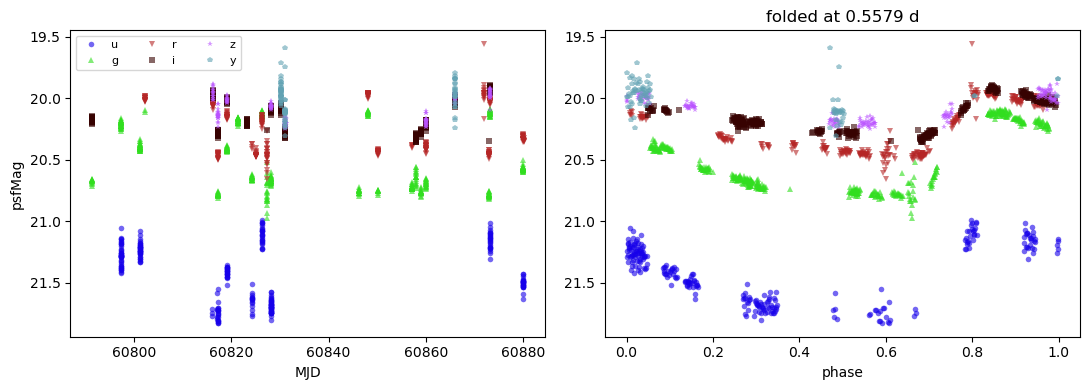

In [9]:
best_id = 744856867972317323
t, mag, band = lcs[best_id]
row = results[results['diaObjectId'] == best_id].iloc[0]
period = row['period_1']
print(f"diaObjectId={best_id}  period_1={period:.4f} d  power_1={row['power_1']:.3f}  "
      f"snr_1={row['snr_1']:.1f}  window_1={row['window_1']:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for b in filter_colors:
    m = band == b
    if m.sum() == 0:
        continue
    ax1.plot(t[m], mag[m], filter_symbols[b], color=filter_colors[b], ms=4, mew=0, alpha=0.6, label=b)
    phase = np.mod(t[m] / period, 1.0)
    ax2.plot(phase, mag[m], filter_symbols[b], color=filter_colors[b], ms=4, mew=0, alpha=0.6)
ax1.invert_yaxis(); ax1.set_xlabel('MJD'); ax1.set_ylabel('psfMag'); ax1.legend(ncol=3, fontsize=8)
ax2.invert_yaxis(); ax2.set_xlabel('phase'); ax2.set_title(f'folded at {period:.4f} d')
plt.tight_layout()
plt.show()

## 7. Is this a known variable?

r~20 is bright enough that a real, coherent 0.56 d signal like this should already be in one of the standard variable-star catalogs, if anyone's looked. Cross-match by coordinates against GCVS, AAVSO's VSX (the modern, continuously-updated successor to GCVS), the ASAS-SN variable catalog, SIMBAD generally, and Gaia DR3's own variable classification -- all reachable directly from this kernel (outbound internet works here; checked before relying on it). OGLE is skipped: its VizieR catalogs only cover the Galactic bulge, Magellanic Clouds, and a few dwarf galaxies -- nowhere near (RA, Dec) = (225, -40).

In [10]:
from astroquery.vizier import Vizier
from astroquery.simbad import Simbad
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
import astropy.units as u

# gotcha: diaObjectId (int64, ~7e17) exceeds float64's exact-integer range (2^53) -- building
# a mixed-dtype row view with .iloc[0] on a frame containing it can throw a pyarrow error.
# Per-column access sidesteps it.
mask = field_df['diaObjectId'] == best_id
target_ra = field_df.loc[mask, 'ra'].iloc[0]
target_dec = field_df.loc[mask, 'dec'].iloc[0]
coord = SkyCoord(ra=target_ra * u.deg, dec=target_dec * u.deg)
print(f"target: RA={target_ra:.5f} Dec={target_dec:.5f}")

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).
target: RA=224.82633 Dec=-39.61812


In [11]:
search_radius = 15 * u.arcsec
vizier = Vizier(columns=['*'])

for catalog_id, label in [("B/gcvs/gcvs_cat", "GCVS"), ("B/vsx/vsx", "AAVSO VSX"),
                          ("II/366/catalog", "ASAS-SN variables")]:
    result = vizier.query_region(coord, radius=search_radius, catalog=catalog_id)
    n = len(result[0]) if len(result) else 0
    print(f"{label}: {n} match(es) within {search_radius}")

simbad_result = Simbad.query_region(coord, radius=search_radius)
print(f"SIMBAD: {len(simbad_result) if simbad_result is not None else 0} match(es) within {search_radius}")

GCVS: 0 match(es) within 15.0 arcsec
AAVSO VSX: 0 match(es) within 15.0 arcsec
ASAS-SN variables: 0 match(es) within 15.0 arcsec


SIMBAD: 0 match(es) within 15.0 arcsec


Gaia DR3 directly (not the VizieR mirror) -- both its variability flag and whether it detected the source at all, since a non-detection and a detected-but-not-flagged-variable are different findings.

In [12]:
Gaia.ROW_LIMIT = 20
gaia_query = f"""SELECT source_id, ra, dec, phot_g_mean_mag, phot_variable_flag
FROM gaiadr3.gaia_source
WHERE 1=CONTAINS(POINT('ICRS', ra, dec),
                 CIRCLE('ICRS', {target_ra}, {target_dec}, {(search_radius.to(u.deg)).value}))"""
gaia_result = Gaia.launch_job(gaia_query).get_results()
print(f"Gaia DR3: {len(gaia_result)} source(s) within {search_radius}")
gaia_result

Gaia DR3: 4 source(s) within 15.0 arcsec


source_id,ra,dec,phot_g_mean_mag,phot_variable_flag
,deg,deg,mag,
int64,float64,float64,float32,object
6197454567644554752,224.82521150665227,-39.61895864461033,19.371029,NOT_AVAILABLE
6197454498932635776,224.8263296064415,-39.61812290832695,20.096657,NOT_AVAILABLE
6197454498932652288,224.8257278898637,-39.61997895309301,20.764687,NOT_AVAILABLE
6197454503225406080,224.83093505707,-39.616104741137356,18.032787,NOT_AVAILABLE


**Not in GCVS, VSX, ASAS-SN, or SIMBAD.** Gaia DR3 *does* detect a source at essentially this exact position (sub-arcsec) at G~20.1 -- consistent with our r~20 -- but `phot_variable_flag = NOT_AVAILABLE`: seen, not flagged as variable. Exactly the "too shallow for Gaia" expectation -- Gaia's own per-epoch photometry and cadence aren't enough to catch a 0.56 d signal at this magnitude, even though the source itself is well within its detection range.

As far as these catalogs go, this looks like a genuinely new variable-star detection from DP2.

## 8. Full periodograms, side by side with the window function

Top-3 peaks is enough to rank candidates, but not to *see* how the window shapes a periodogram. A pandas note first, since the cross-match above just ran into it: `diaObjectId` (int64, ~7e17) is past float64's exact-integer range (2^53) -- `.iloc[0]` on a slice mixing it with float columns doesn't just risk an error, it can silently corrupt the id (`744856867972317323` -> `744856867972317312`, no warning) by upcasting the whole row to one common dtype. Pulling a single column out on its own, as below, never upcasts and is the safe pattern -- casting to string, as in some of my other notebooks, is a fine alternative when an id has to live alongside other columns.

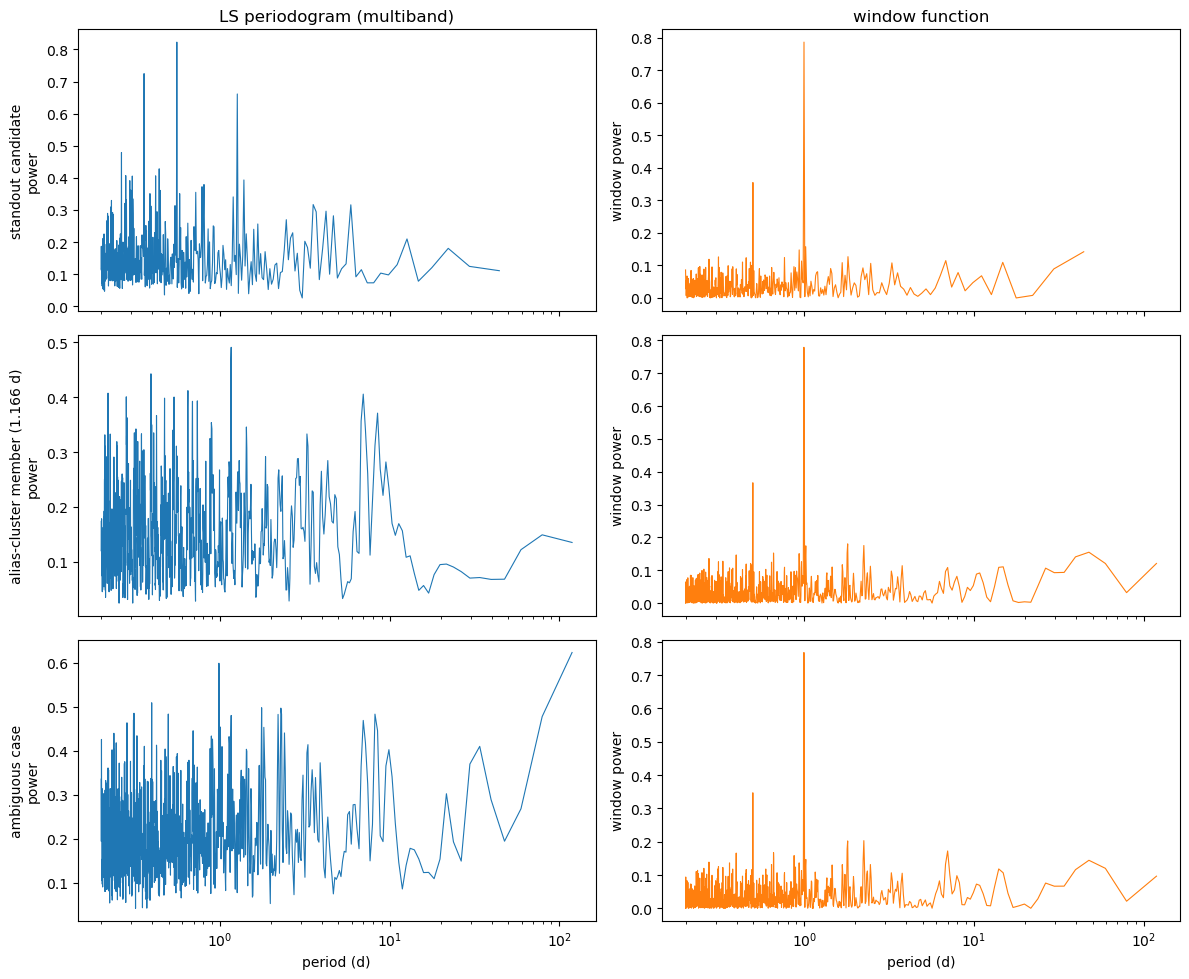

In [13]:
showcase_ids = [744856867972317323, 744857623886562277, 744857555167086745]
showcase_labels = ["standout candidate", "alias-cluster member (1.166 d)", "ambiguous case"]

fig, axes = plt.subplots(len(showcase_ids), 2, figsize=(12, 3.3 * len(showcase_ids)), sharex='col')
for row, (oid, label) in enumerate(zip(showcase_ids, showcase_labels)):
    t, mag, band = lcs[oid]
    max_period = (t.max() - t.min()) / 2
    ls = LombScargleMultiband(t, mag, band)
    freq, power = ls.autopower(minimum_frequency=1 / max_period, maximum_frequency=1 / MIN_PERIOD_DAYS,
                               samples_per_peak=1, method='flexible')
    window = spectral_window_power(t, freq)
    periods = 1 / freq

    axes[row, 0].plot(periods, power, lw=0.8, color='C0')
    axes[row, 0].set_ylabel(f"{label}\npower")
    axes[row, 1].plot(periods, window, lw=0.8, color='C1')
    axes[row, 1].set_ylabel("window power")
    for ax in axes[row]:
        ax.set_xscale('log')

axes[0, 0].set_title("LS periodogram (multiband)")
axes[0, 1].set_title("window function")
axes[-1, 0].set_xlabel("period (d)")
axes[-1, 1].set_xlabel("period (d)")
plt.tight_layout()
plt.show()

The window function (right column) is nearly identical for all three -- expected, since they share almost the same visit sampling -- with two sharp, unmistakable spikes at 1.0 d and 0.5 d, the classic ground-based diurnal alias. It's not just injecting a couple of spurious peaks: the whole periodogram's broad shape (the rise-dip-rise past ~10 d, the forest of sub-day peaks) tracks the window's own shape in all three objects, real signal or not.

The standout candidate's periodogram (top left) has one relatively isolated peak that's tall *and* clear of both the 1.0 d and 0.5 d window spikes -- that's what a real signal riding on top of this window looks like. The other two show their tallest peaks sitting on or immediately next to a window spike.